# Solution Using Eigenvectors

In [1]:
!TZ=America/Los_Angeles date

Mon Oct 22 14:27:14 PDT 2018


In [Section 4](https://link.springer.com/article/10.1007/s00285-017-1190-x#Sec12), the differential-equation model in [Equation 3.2](https://link.springer.com/article/10.1007/s00285-017-1190-x#Equ8), giving the rate of change in the frequency distribution (vector) $\mathbf{P},$ is rewritten

$$\mathbf{P^\prime} = W \mathbf{P},$$

where the general element of matrix $W$ is

$$w_{ij} = b_{j} f_{ij} - d_i \delta_{ij},$$

and

\begin{align*}
   \delta_{ij} = \begin{cases}
                     1 \text{ if } i = j \\
                     0 \text{ otherwise.}
                 \end{cases}
\end{align*}

According to Basener and Sanford:

>The sole equilibrium solution is the $\mathbf{P=0}$ [*sic*], and all other solutions will be asymptotic to the eigenvector corresponding to the largest eigenvalue of $W.$

The latter part of the claim is dubious, because a process with the population initially comprised of only the least-fit of fitness classes, for which there are no births, will always have a population comprised entirely of that class. (With no births, the frequency of the least-fit class decreases exponentially from its initial value of unity.) Here we solve for the frequency distribution at time $t$ in terms of the eigenvectors of $W,$ and compare the result to what we obtain using an ODE solver.

In [2]:
%matplotlib notebook
%run ../Code/bs.py
%run -i ../Code/multiprecision_gamma.py
%run -i ../Code/gamma.py

## Define the distribution of probability over mutation effects

The probabilities are multiprecision floating-point numbers.

In [3]:
%%time

def define_distribution(delta='5e-4', weight='1e-3'):
    max_fitness = 0.1
    min_fitness = -0.1
    n_types = round((max_fitness - min_fitness) / float(delta)) + 1
    factors = Factors(n_types, death=-min_fitness, max_growth=max_fitness)
    # The type of the mutation effects determines the type of the probabilities.
    factors.effects = mp_float(factors.effects)
    return WeightedDoubleGamma(factors, weight=mp_float(weight))

fraction_beneficial = '1e-3'
mutations = define_distribution(delta='2e-3', weight=fraction_beneficial)

CPU times: user 22.8 ms, sys: 370 µs, total: 23.2 ms
Wall time: 23.4 ms


Check the type of one of the probabilities in the mutation distribution, and verify that it is multiprecision floating point (`mpf`).

In [4]:
type(mutations[0])

mpmath.ctx_mp_python.mpf

Now normalize the distribution.

In [5]:
mutations.normalize()

Convert the probabilities to conventional floating-point numbers.

In [6]:
mutations.convert(float)

## Define the initial frequency distribution over fitness classes

In [7]:
init = GaussianFrequencies(mutations.factors, mean=0, std=0.015, crop=np.inf, density=False)

## Define the population

In [8]:
pop = Population(init, mutations, label=fraction_beneficial+' beneficial', matrix=True)

## Solve for frequency distribution at time $t$ in terms of eigenvectors

In [9]:
%%time
pop.solve()

CPU times: user 14.9 ms, sys: 0 ns, total: 14.9 ms
Wall time: 15.3 ms


/home/tom_english_phd/Notebooks/BS/Code/bs.py:271: LinAlgWarning: scipy.linalg.solve
Ill-conditioned matrix detected. Result is not guaranteed to be accurate.
Reciprocal condition number5.621398e-21
  self.c = la.solve(self.e_vectors, self.initial_freqs)


<IPython.core.display.Javascript object>


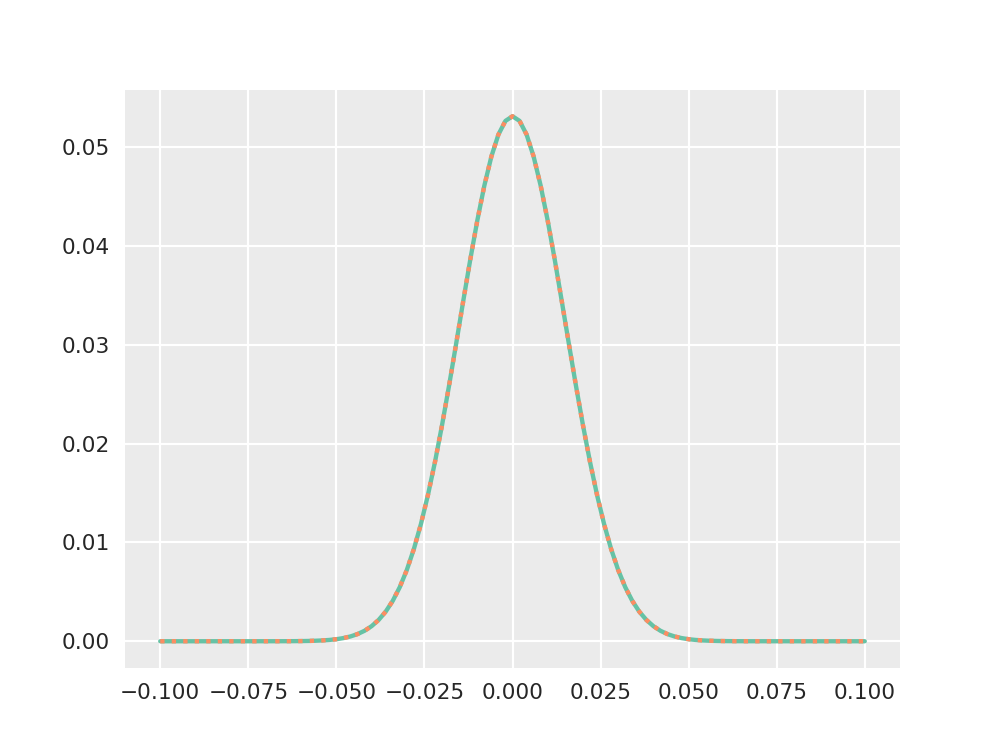

In [10]:
solution = pop.solution(0)
plt.plot(mutations.factors.growth, solution, label='solution')
plt.plot(mutations.factors.growth, init, label='initial', ls=':')

## Check against result produced by ODE solver

In [14]:
ev = Evolution(pop, n_epochs=5000, years_per_epoch=1, use_ode_solver=True)
ev(5000)
len(ev)

10001

In [17]:
def plot(t):
    solution = pop.solution(t)
    i = np.argmax(pop.e_values.real)
    dominant = pop.e_vectors[:, i].real
    plt.plot(mutations.factors.growth, solution / accurate_sum(solution), label='eigen solver')
    plt.plot(mutations.factors.growth, ev[t] / accurate_sum(ev[t]), label='ODE solver', ls='--')
    plt.plot(mutations.factors.growth, dominant / accurate_sum(dominant), label='dominant', ls=':')
    plt.legend(loc='best')

<IPython.core.display.Javascript object>


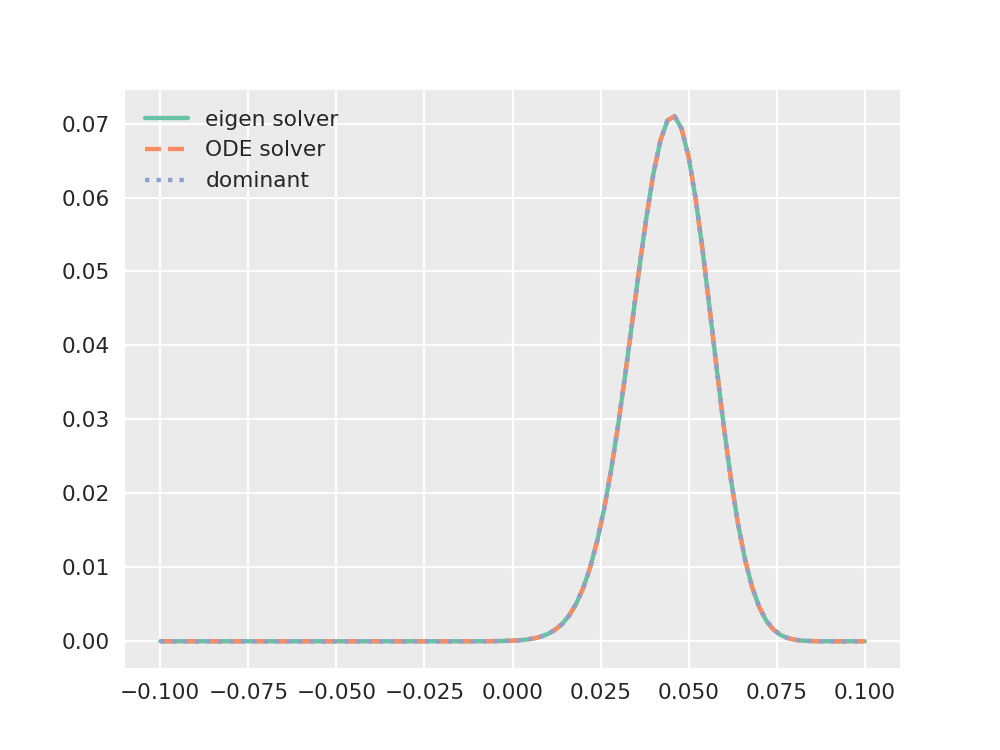

In [19]:
plt.close()
plot(5000)

In [ ]:
np.argmax(pop.e_values[0:].real)